# Projet d'Optimisation et Machinne learning

Membres: Charles Pilleur, Ancco Jhonatan

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#  Classificateur multiclasse de la base de données UCI HAR:

https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones

Les données utilisées proviennent d’expériences menées avec un groupe de 30 volontaires, âgés de 19 à 48 ans.
Chaque participant a exécuté six activités différentes : WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING et LAYING, tout en portant un smartphone Samsung Galaxy S II fixé à la taille.

Chaque enregistrement du jeu de données contient :

l’accélération triaxiale totale et l’accélération corporelle estimée,

la vitesse angulaire triaxiale issue du gyroscope,

un vecteur de 561 caractéristiques,

l’étiquette d’activité correspondante,

et l’identifiant du sujet ayant effectué l’expérience.

Le but final est d’utiliser ces caractéristiques pour entraîner un modèle de classification supervisée capable de reconnaître automatiquement l’activité physique réalisée par un individu à partir des signaux des capteurs du smartphone.

In [33]:
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split

X_train = np.loadtxt('/content/drive/MyDrive/DataProjetOpti/train/X_train.txt')
y_train = np.loadtxt('/content/drive/MyDrive/DataProjetOpti/train/y_train.txt')
X_test = np.loadtxt('/content/drive/MyDrive/DataProjetOpti/test/X_test.txt')
y_test = np.loadtxt('/content/drive/MyDrive/DataProjetOpti/test/y_test.txt')


Training shape: (7352, 561), Labels: (7352,)
Test shape: (2947, 561), Labels: (2947,)
Training shape: torch.Size([7300, 560]), Labels: (7300,)
Test shape: torch.Size([2900, 560]), Labels: (2900,)


# Fonction à optimiser
$$
\min_{x\in\mathbb{R}^{(M+1)K}}  g(x) + \lambda h(x),
$$
où
$$
h(x) = \sum_{\ell=1}^{L}
\log\Big(1 + \sum_{k\ne\ell}
\exp\big[\mu_\ell + \varphi(u_\ell)^\top(x^{(k)} - x^{(z_l)})\big]\Big),
$$
$$
x^{(k)} = [w^{(k)}; b^{(k)}] \in \mathbb{R}^{M+1},
$$
$$
g(x) = \sum_{k=1}^{K} \|w^{(k)}\|_1, \,
$$
avec :

- ${\mu_\ell = 1}$ : Marge fixée à 1 pour tous les échantillons

- ${\phi({u_\ell}) = [{u_\ell}^\top, 1]^\top \in \mathbb{R}^{M+1}}$ : Transformation qui ajoute un biais de 1.

- ${x^{(k)} \in \mathbb{R}^{M+1}}$ : Paramètres pour la classe $k$ (vecteur de poids + biais).

- ${({u_\ell}, z_\ell)}$ : $\ell$-ème échantillon d'entraînement (vecteur, classe).

---


In [34]:
def phi(u):
def extract_weights_biases_torch(x, N, K):
def g_reg_torch(x, N, K):
def h_loss_torch(x, X_train, y_train, mu=1.0, K=6):
def objective_function_torch(x, X_train, y_train, lambda_reg, mu=1.0, K=6):

**Formulation pour l'algorithme de Condat**

L'algorithme de Condat résout des problèmes de la forme :
$$
\min_x f(x) + g(x)
$$

Pour notre problème de classification multiclasse avec régularisation $l_1$, nous utilisons la perte logistique comme fonction différentiable et la norme $l_1$ comme régularisation non-différentiable :

$$
\min_x \underbrace{\lambda \sum_{\ell=1}^{L} \log\Big(1 + \sum_{k \neq z_\ell} \exp\big[1 + \varphi(u_\ell)^\top(x^{(k)} - x^{(z_\ell)})\big]\Big)}_{f(x)} + \underbrace{\sum_{k=1}^K \|w^{(k)}\|_1}_{g(x)}
$$

Dans cette formulation :

- $f(x)=\lambda *h(x)$ est la perte logistique multipliée par $\lambda$, fonction différentiable.

- $g(x)$ est la norme $l_1$ sur les poids, fonction non-différentiable mais proximable.





In [35]:
def grad_f(x_val, X_train, y_train, lambda_reg, mu, K):
def prox_g(v, tau_prox, N, K):

Les étapes d'itération sont les suivantes :

**Initialisation :**

- $x^0, y^0 \in \mathbb{R}^{(M+1)K}$.

- $\tau > 0$ (pas d'algorithme)

- $\rho \in (0, 2)$ (paramètre de relaxation)

**Pour $k = 0, 1, 2, \dots$ :**



In [36]:
def estimate_lipschitz_constant(X_train, y_train, lambda_reg):
print("tau<",2/estimate_lipschitz_constant(X_train, y_train, lambda_reg))

mu=1
tau=1e-6
rho=1
tol=1e-5

tau< 2.0685172158721704e-06


1. **Mise à jour de $x$ (variable primale pour $g$)** :
   $$p^{k+1} = \text{prox}_{\tau g}(x^k - \tau (\nabla f(x^k)))$$

In [37]:
grad_f_x = grad_f(x_current, X_train_torch, y_train_torch, lambda_reg, mu, K)
arg_prox_g = x_current - tau * (grad_f_x)
p_new = prox_g(arg_prox_g, tau, N, K)

2. **Mise à jour de $x$ avec relaxation (variable primale extrapolée pour $f$)** :
   $$x^{k+1} = x^k + \rho (p^{k+1} - x^k)$$


In [38]:
x_new = x_current + rho * (p_new - x_current)

**Critère d'arrêt :**
Le critère d'arrêt sera basé sur la norme de la différence entre $x^{k+1}$ et $x^k$, ainsi que l'évolution des variables duales.

In [39]:
if torch.linalg.norm(x_new - x_old) < tol:
  print(f"\nConvergence atteinte à l'itération {iteration+1}")

Construction de notre algorithme.

In [40]:
def condat_algorithm_torch(x0, X_train_torch, y_train_torch, lambda_reg,
                                            ...):
    ...
    if save_x_at_iters is not None:
        return x_current.detach(), x_history
    else:
        return x_current.detach()

Évaluation de la méthode avec 2000 itérations

In [41]:
x0_torch = torch.zeros((N_features + 1) * K_classes, dtype=torch.float32)

obj_init_torch = lambda_reg * h_loss_torch(x0_torch, X_train_torch, y_train_torch, mu, K) \
                 + g_reg_torch(x0_torch, N_features, K)

x_optimal_torch = condat_algorithm_torch(...,tau=2.06e-6,rho=1.5,...)


Initialisation: vecteur x0 de taille 3366
Valeur objectif initiale: 19567.1602

DÉBUT DE L'OPTIMISATION FORWARD-BACKWARD (PyTorch)
Début optimisation (Condat):
  Objectif initial = 19567.1602
  Dimensions: 7300 échantillons, 560 features, 6 classes
  Hyperparamètres: tau=2.06e-06, rho=1.5
Iter    0: h=18323.1875, g=3.5152, obj=18326.7031
Iter  100: h=7240.2261, g=63.2598, obj=7303.4858
Iter  200: h=5415.6289, g=87.4591, obj=5503.0879
Iter  300: h=4570.1841, g=103.4968, obj=4673.6812
Iter  400: h=4061.1797, g=115.6805, obj=4176.8604
Iter  500: h=3709.1724, g=125.5875, obj=3834.7600
Iter  600: h=3444.6450, g=134.0544, obj=3578.6995
Iter  700: h=3234.8818, g=141.5082, obj=3376.3901
Iter  800: h=3062.2998, g=148.1708, obj=3210.4707
Iter  900: h=2916.5232, g=154.2002, obj=3070.7234
Iter 1000: h=2790.9395, g=159.6984, obj=2950.6379
Iter 1100: h=2681.1003, g=164.7495, obj=2845.8499
Iter 1200: h=2583.8765, g=169.4261, obj=2753.3025
Iter 1300: h=2496.9775, g=173.7906, obj=2670.7681
Iter 1400: 

Prédiction utilisant notre $x_N$ appris.

In [42]:
def predict_torch(x, X_data, N, K, unique_labels_torch):
    return predicted_labels

from sklearn.metrics import classification_report, confusion_matrix

unique_labels_torch = torch.from_numpy(np.unique(y_train)).float()

y_pred_condat = predict_torch(x_optimal_torch, X_test_torch, N_features, K, unique_labels_torch)
y_true_torch = y_test_torch
accuracy_condat = torch.mean((y_pred_condat == y_true_torch).float())


Accuracy on reduced test set (PyTorch Primal-Dual Condat-like): 0.9372

Classification Report (Reduced Test Set - PyTorch Primal-Dual Condat-like):
              precision    recall  f1-score   support

         1.0       0.93      0.99      0.96       496
         2.0       0.92      0.94      0.93       441
         3.0       0.96      0.89      0.92       403
         4.0       0.92      0.87      0.90       491
         5.0       0.89      0.93      0.91       532
         6.0       1.00      1.00      1.00       537

    accuracy                           0.94      2900
   macro avg       0.94      0.93      0.94      2900
weighted avg       0.94      0.94      0.94      2900


Confusion Matrix (Reduced Test Set - PyTorch Primal-Dual Condat-like):
[[489   0   7   0   0   0]
 [ 22 413   6   0   0   0]
 [ 16  30 357   0   0   0]
 [  0   3   0 427  60   1]
 [  1   1   0  35 495   0]
 [  0   0   0   0   0 537]]


Comparaison du méthode avec $\rho$ variable.

Initial Accuracy (x0): 0.1710

Running Condat algorithm with rho=0.5, tau=1e-06
  Accuracies for rho=0.5: ['0.5500', '0.6676', '0.7966', '0.8331', '0.8466', '0.8566', '0.8593', '0.8641', '0.8679', '0.8700', '0.8724']

Running Condat algorithm with rho=1.0, tau=1e-06
  Accuracies for rho=1.0: ['0.6676', '0.7966', '0.8469', '0.8593', '0.8679', '0.8724', '0.8766', '0.8814', '0.8855', '0.8869', '0.8890']

Running Condat algorithm with rho=1.5, tau=1e-06
  Accuracies for rho=1.5: ['0.7555', '0.8331', '0.8593', '0.8703', '0.8766', '0.8852', '0.8869', '0.8900', '0.8952', '0.9014', '0.9059']


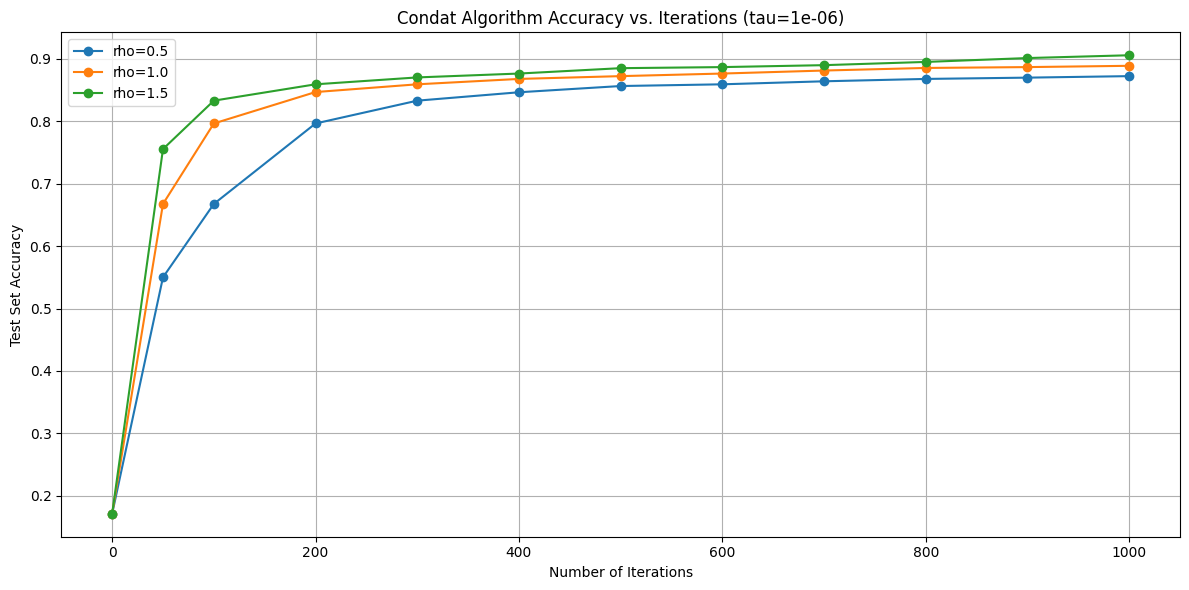

In [43]:
import matplotlib.pyplot as plt

def compare_condat_rhos(rho_values,fixed_tau,...):

iteration_counts = [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
max_total_iter_condat = max(iteration_counts) + 1
fixed_tau = tau

rho_values_to_compare = [0.5, 1.0, 1.5]

compare_condat_rhos(rho_values=rho_values_to_compare,fixed_tau=fixed_tau,...)

# Methode ADMM


On introduit une variable auxiliaire $z$ pour découpler les deux termes :

$$
\begin{aligned}
\min_{x,z} & \quad \lambda h(x) + g(z) \\
\text{s.t.} & \quad x - z = 0
\end{aligned}
$$

où :


- $x$ porte la perte logistique (différentiable).

- $z$ porte la régularisation L1 (non-différentiable).

### **Lagrangien Augmenté :**
$$
\mathcal{L}_\rho(x, z, u) = \lambda h(x) + g(z) + u^T(x - z) + \frac{\rho}{2}\|x - z\|_2^2
$$

avec :

- $u \in \mathbb{R}^{(M+1)K}$ : multiplicateur de Lagrange.

- $\rho > 0$ : paramètre de pénalité.

## **Algorithme ADMM - Étapes Itératives**

### **Initialisation :**
$$
x^0, z^0, u^0 \in \mathbb{R}^{(M+1)K} \quad \text{(souvent nuls)}, \quad \rho > 0
$$

### **Itération $t = 0, 1, 2, \dots$ :**

#### **Étape 1 : Mise à jour de $x$**
$$
x^{t+1} = \arg\min_{x} \left[ \lambda h(x) + \frac{\rho}{2}\|x - z^t + u^t\|_2^2 \right]
$$
C'est un problème lisse qu'on résout par **descente de gradient** :
$$
\nabla_x \mathcal{L} = \lambda \nabla h(x) + \rho(x - z^t + u^t)
$$



On va resoudre ce proble avec une tolerance $10^{-2}$,pas d'apprentisage $10^{-4}$ et nombre d'iterations limite $20$.



In [44]:
def solve_x_subproblem(..., inner_max_iter=20, inner_tol=1e-5, inner_alpha=1e-4):
    return x_sub.detach()

#### **Étape 2 : Mise àjour de $z$**
$$
z^{t+1} = \arg\min_{z} \left[ g(z) + \frac{\rho}{2}\|x^{t+1} - z + u^t\|_2^2 \right]
$$

Pour $g(z) = \|w_z\|_1$, solution par **soft-thresholding** :

Pour chaque classe $k$ et chaque composante $i$ :
$$
w_{z,i}^{(k)} = \mathcal{S}_{\frac{1}{\rho}}\left(x_{w,i}^{(k)} + u_{w,i}^{(k)}\right)
$$
où $\mathcal{S}_\kappa(a) = \operatorname{sign}(a) \max(|a| - \kappa, 0)$

Les biais restent inchangés :
$$
b_z^{(k)} = x_b^{(k)} + u_b^{(k)}
$$

#### **Étape 3 : Mise à jour du multiplicateur**
$$
u^{t+1} = u^t + (x^{t+1} - z^{t+1})
$$

## **Conditions de Convergence**

### **Critères d'Arrêt :**

#### **Résidu Primal :**
$$
r^{t+1} = x^{t+1} - z^{t+1}
$$
Mesure la violation de contrainte.

#### **Résidu Dual :**
$$
s^{t+1} = \rho(z^{t+1} - z^t)
$$
Mesure le changement dans les variables duales.

#### **Condition de Convergence :**
L'algorithme s'arrête quand :
$$
\|r^{t+1}\|_2 \leq \epsilon^{\text{primal}} \quad \text{et} \quad \|s^{t+1}\|_2 \leq \epsilon^{\text{dual}}
$$
avec $\epsilon^{\text{primal}} = tol + tol \max(\|x^t\|_2, \|z^t\|_2)$


In [45]:
def admm_solver_torch(..., rho=1.0, max_iter=100, tol=1e-4, mu=1.0, K=6, x_solver=None, save_x_at_iters=None):
        # ===== Étape 1 : Mise à jour de x =====
        x = x_solver(x, z, u, lambda_reg, rho, X_train_torch, y_train_torch, mu, K,
                               inner_max_iter=20, inner_tol=1e-2, inner_alpha=alpha_x_update)
        x.requires_grad_(True) # Ensure x can accumulate gradients in the next ADMM iteration
        # ===== Étape 2 : Mise à jour de z =====
        v = x.detach() + u # detach x as z's update does not depend on x's gradient
        # tau_scaled for prox_soft_thresholding_torch is 1/rho
        z = prox_g(v, 1/rho, N, K)
        # ===== Étape 3 : Mise à jour du multiplicateur =====
        u = u + x.detach() - z # detach x as u's update does not depend on x's gradient

        # ===== Vérification de la convergence =====
        primal_res = torch.linalg.norm(x.detach() - z)
        dual_res = rho * torch.linalg.norm(z - z_old)
        eps_primal = tol + tol * torch.max(torch.linalg.norm(x.detach()), torch.linalg.norm(z))
        eps_dual = tol + tol * rho * torch.linalg.norm(u)

        if primal_res < eps_primal and dual_res < eps_dual:
            print(f"ADMM converged at iteration {it}")
            break

Évaluons la méthode ADMM.

In [46]:
def apply_and_evaluate_solver(...):
    return x_optimal, accuracy

lambda_reg_admm = 1.0
rho_admm = 1.0

x_admm_optimal, accuracy_admm = apply_and_evaluate_solver(...)


APPLICATION DE LA MÉTHODE ADMM_SOLVER_TORCH (PyTorch)
ADMM Iter    0: Obj = 21367.1875, Primal = 1.4658, Dual = 0.0545
ADMM Iter  100: Obj = 1553.4216, Primal = 0.2669, Dual = 0.0526
ADMM Iter  199: Obj = 1526.0088, Primal = 0.0876, Dual = 0.0094

Accuracy avec admm_solver_torch (PyTorch): 0.9493

Classification Report (admm_solver_torch PyTorch):
              precision    recall  f1-score   support

         1.0       0.94      0.99      0.97       496
         2.0       0.94      0.94      0.94       441
         3.0       0.98      0.93      0.95       403
         4.0       0.95      0.88      0.91       491
         5.0       0.90      0.95      0.92       532
         6.0       1.00      1.00      1.00       537

    accuracy                           0.95      2900
   macro avg       0.95      0.95      0.95      2900
weighted avg       0.95      0.95      0.95      2900


Confusion Matrix (admm_solver_torch PyTorch):
[[491   1   4   0   0   0]
 [ 20 416   5   0   0   0]
 [  8

Évaluons la méthode avec different valeurs de $\rho$



Initial Accuracy (x0): 0.1710

Running ADMM algorithm with rho=0.01
ADMM Iter    0: Obj = 21365.0566, Primal = 1.4659, Dual = 0.0005
ADMM Iter  100: Obj = 1575.2555, Primal = 8.3083, Dual = 0.0000
ADMM Iter  200: Obj = 1546.3583, Primal = 7.0436, Dual = 0.0000
ADMM Iter  300: Obj = 1521.7268, Primal = 6.0942, Dual = 0.0000
  Accuracies for rho=0.01: ['0.9448', '0.9497', '0.9500', '0.9503']

Running ADMM algorithm with rho=1.0
ADMM Iter    0: Obj = 21367.1875, Primal = 1.4658, Dual = 0.0545
ADMM Iter  100: Obj = 1553.4216, Primal = 0.2669, Dual = 0.0526
ADMM Iter  200: Obj = 1525.7590, Primal = 0.0875, Dual = 0.0063
ADMM Iter  300: Obj = 1501.8176, Primal = 0.0497, Dual = 0.0016
  Accuracies for rho=1.0: ['0.9428', '0.9490', '0.9493', '0.9493']

Running ADMM algorithm with rho=5
ADMM Iter    0: Obj = 21375.4863, Primal = 1.4047, Dual = 0.9288
ADMM Iter  100: Obj = 1551.6238, Primal = 0.0872, Dual = 0.1059
ADMM Iter  200: Obj = 1524.0247, Primal = 0.0199, Dual = 0.0097
ADMM Iter  300: Ob

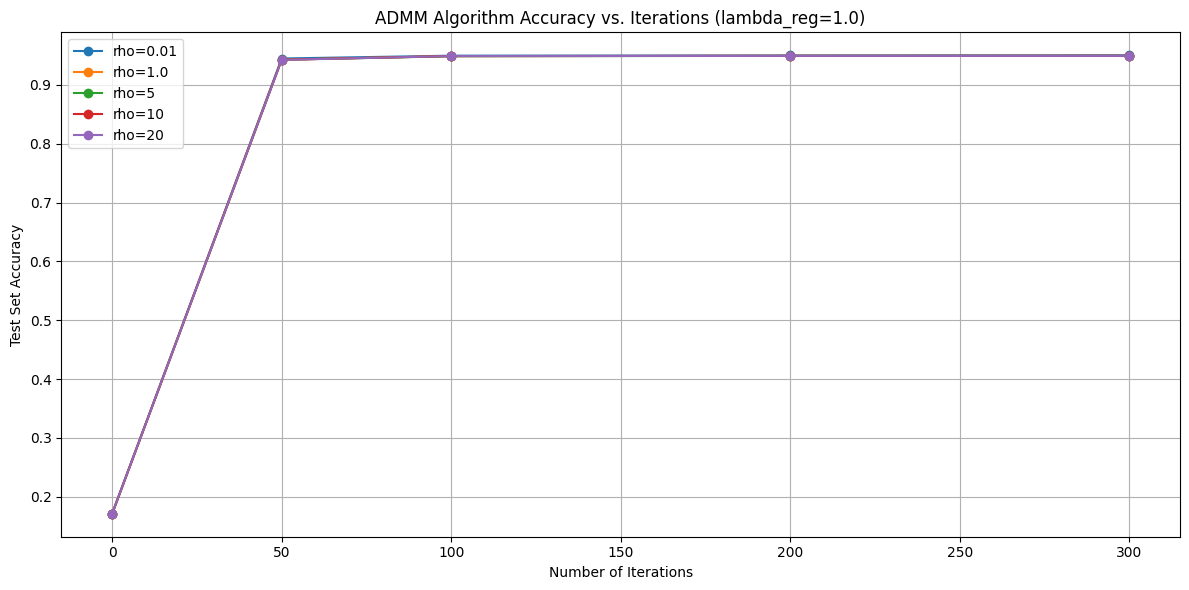

In [47]:
def compare_admm_rhos(rho_values,...):

iteration_counts = [50, 100, 200, 300]
rho_values_to_compare_admm = [0.01, 1.0, 5,10,20]

compare_admm_rhos(
    rho_values=rho_values_to_compare_admm,
    ...
)

Il n'y a pas de changement visible ; modifions donc le pas d'apprentissage pour résoudre $x^{t+1}$.

In [48]:
def admm_solver_torch(..., inner_alpha_x_sub=None):

On va comparer les alpha_inner [1e-6, 1e-5, 1e-4] avec un $\rho=1$ fixé.

Initial Accuracy (x0): 0.1710

Running ADMM algorithm with fixed_rho=1.0, inner_alpha_x_sub=1e-06
ADMM Iter    0: Obj = 15685.4150, Primal = 0.2659, Dual = 0.0076
ADMM Iter  100: Obj = 10218.2061, Primal = 0.3643, Dual = 0.0410
ADMM Iter  200: Obj = 8298.8740, Primal = 0.1396, Dual = 0.0209
ADMM Iter  300: Obj = 7180.5796, Primal = 0.0814, Dual = 0.0050
ADMM Iter  400: Obj = 6434.2715, Primal = 0.0642, Dual = 0.0072
  Accuracies for inner_alpha=1e-06: ['0.7559', '0.8152', '0.8521', '0.8624', '0.8690']

Running ADMM algorithm with fixed_rho=1.0, inner_alpha_x_sub=1e-05
ADMM Iter    0: Obj = 21367.1875, Primal = 1.4658, Dual = 0.0545
ADMM Iter  100: Obj = 1553.4216, Primal = 0.2669, Dual = 0.0526
ADMM Iter  200: Obj = 1525.7590, Primal = 0.0875, Dual = 0.0063
ADMM Iter  300: Obj = 1501.8176, Primal = 0.0497, Dual = 0.0016
ADMM Iter  400: Obj = 1479.7250, Primal = 0.0412, Dual = 0.0015
  Accuracies for inner_alpha=1e-05: ['0.9428', '0.9490', '0.9493', '0.9493', '0.9486']

Running ADMM alg

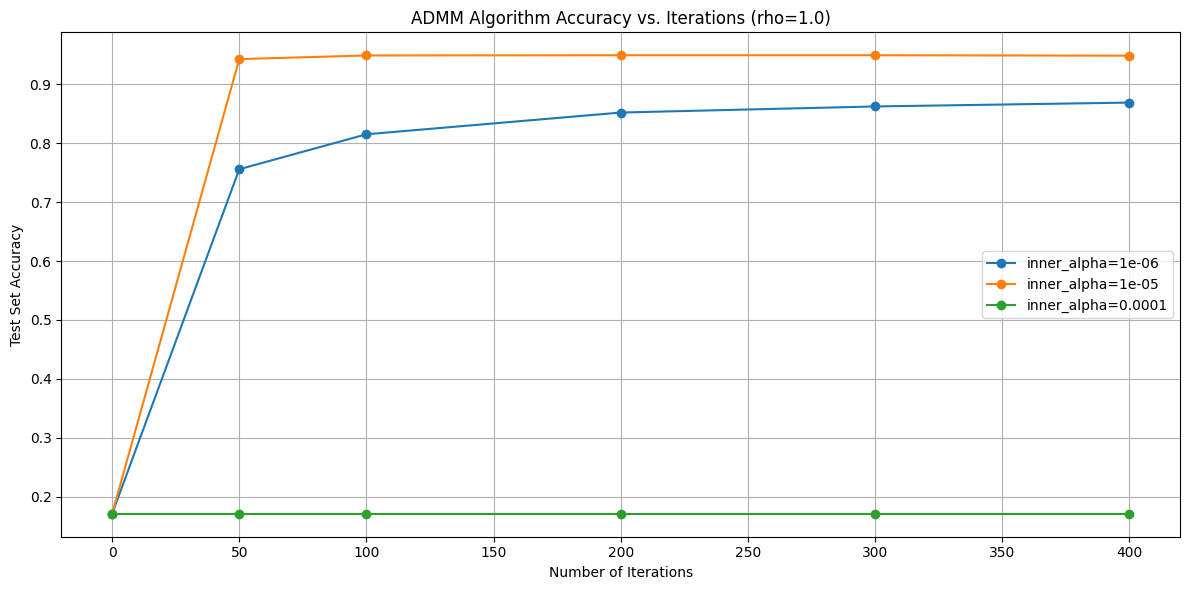

In [49]:
import matplotlib.pyplot as plt

def compare_admm_inner_alphas(inner_alpha_values,fixed_rho,...):

# Define the inner_alpha values to compare
inner_alpha_values_to_compare = [1e-6, 1e-5, 1e-4]
fixed_rho = 1.0 # Using a fixed rho for this comparison

# Call the comparison function
compare_admm_inner_alphas(
    inner_alpha_values=inner_alpha_values_to_compare,
    fixed_rho=fixed_rho,
    ...
)

Pour trouver le bon pas d'apprentissage, qui dépend de $\rho$ et de $\alpha$, il faut noter que les changements de $\rho$ doivent être extrêmes pour avoir un effet notable.

In [79]:
import torch

def compute_max_alpha_power_iteration(x, lambda_reg, rho, ...):
    return alpha_max, lambda_max

rho=: 1
Estimated largest eigenvalue λ_max: 339896.500000
Theoretical maximum stable step α_max: 0.000006
rho=: 200000
Estimated largest eigenvalue λ_max: 542426.250000
Theoretical maximum stable step α_max: 0.000004


Fixons certains pas d'apprentissage et faisons varier $\rho$ pour observer cette absence d'effet.

Initial Accuracy (x0): 0.1710

Running ADMM algorithm with fixed_rho=1.0, inner_alpha_x_sub=5e-06
ADMM Iter    0: Obj = 11870.7803, Primal = 0.8641, Dual = 0.0267
ADMM Iter  100: Obj = 3713.4158, Primal = 0.1667, Dual = 0.0274
ADMM Iter  200: Obj = 3367.4312, Primal = 0.0791, Dual = 0.0055
ADMM Iter  300: Obj = 3115.5417, Primal = 0.0650, Dual = 0.0108
ADMM Iter  400: Obj = 2920.3967, Primal = 0.0620, Dual = 0.0058
  Accuracies for inner_alpha=5e-06: ['0.9031', '0.9079', '0.9138', '0.9193', '0.9266']

Running ADMM algorithm with fixed_rho=1.0, inner_alpha_x_sub=1e-07
ADMM Iter    0: Obj = 19510.3711, Primal = 0.0024, Dual = 0.0000
ADMM Iter  100: Obj = 17063.4590, Primal = 0.1505, Dual = 0.0002
ADMM Iter  200: Obj = 15692.4941, Primal = 0.1880, Dual = 0.0087
ADMM Iter  300: Obj = 14673.9570, Primal = 0.1490, Dual = 0.0113
ADMM Iter  400: Obj = 13872.4688, Primal = 0.1121, Dual = 0.0084
  Accuracies for inner_alpha=1e-07: ['0.3931', '0.4828', '0.5421', '0.5676', '0.6200']

Running ADMM 

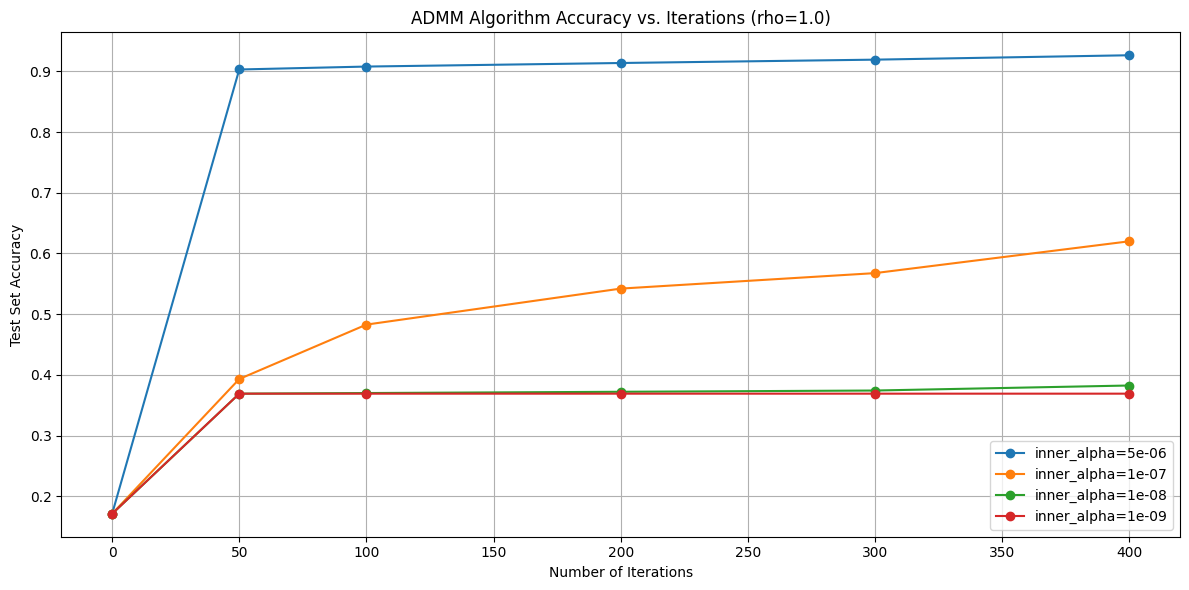

In [51]:
import matplotlib.pyplot as plt

def compare_admm_inner_alphas(
    inner_alpha_values,
    fixed_rho,
    ...
):

inner_alpha_values_to_compare = [5e-6, 1e-7, 1e-8, 1e-9]
fixed_rho = 1.0

compare_admm_inner_alphas(
    inner_alpha_values=inner_alpha_values_to_compare,
    fixed_rho=fixed_rho,
    ...
)

Avec un $\rho = 20$

Initial Accuracy (x0): 0.1710

Running ADMM algorithm with fixed_rho=20.0, inner_alpha_x_sub=5e-06
ADMM Iter    0: Obj = 11875.3643, Primal = 0.7853, Dual = 4.7256
ADMM Iter  100: Obj = 3713.4368, Primal = 0.0104, Dual = 0.1258
ADMM Iter  200: Obj = 3367.0796, Primal = 0.0114, Dual = 0.0946
ADMM Iter  300: Obj = 3115.2615, Primal = 0.0084, Dual = 0.0662
ADMM Iter  400: Obj = 2920.1914, Primal = 0.0061, Dual = 0.0597
  Accuracies for inner_alpha=5e-06: ['0.9028', '0.9079', '0.9138', '0.9193', '0.9266']

Running ADMM algorithm with fixed_rho=20.0, inner_alpha_x_sub=1e-07
ADMM Iter    0: Obj = 19510.3711, Primal = 0.0024, Dual = 0.0009
ADMM Iter  100: Obj = 17065.5820, Primal = 0.0186, Dual = 0.0470
ADMM Iter  200: Obj = 15695.8350, Primal = 0.0140, Dual = 0.0445
ADMM Iter  300: Obj = 14677.3525, Primal = 0.0089, Dual = 0.0263
ADMM Iter  400: Obj = 13875.5195, Primal = 0.0054, Dual = 0.0175
  Accuracies for inner_alpha=1e-07: ['0.3931', '0.4828', '0.5417', '0.5676', '0.6197']

Running ADM

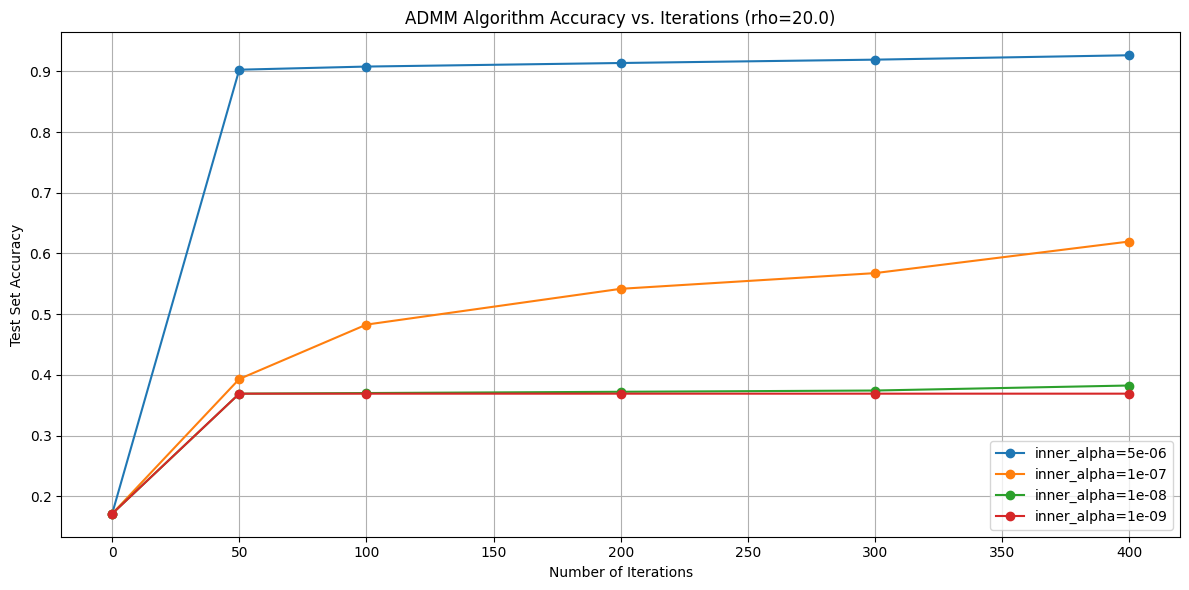

In [52]:
inner_alpha_values_to_compare = [5e-6, 1e-7, 1e-8, 1e-9]
fixed_rho = 20.0

compare_admm_inner_alphas(...)

Avec uniquement des valeurs de inner_alpha proches de la limite :

Initial Accuracy (x0): 0.1710

Running ADMM algorithm with fixed_rho=20.0, inner_alpha_x_sub=2e-07
ADMM Iter    0: Obj = 19454.7188, Primal = 0.0048, Dual = 0.0018
ADMM Iter  100: Obj = 15681.9707, Primal = 0.0243, Dual = 0.0989
ADMM Iter  200: Obj = 13866.3740, Primal = 0.0107, Dual = 0.0342
ADMM Iter  300: Obj = 12648.1045, Primal = 0.0082, Dual = 0.0293
ADMM Iter  400: Obj = 11730.8574, Primal = 0.0050, Dual = 0.0259
  Accuracies for inner_alpha=2e-07: ['0.4821', '0.5417', '0.6197', '0.7072', '0.7659']

Running ADMM algorithm with fixed_rho=20.0, inner_alpha_x_sub=9e-06
ADMM Iter    0: Obj = 21435.2754, Primal = 1.1288, Dual = 10.6130
ADMM Iter  100: Obj = 1699.9990, Primal = 0.0162, Dual = 0.1323
ADMM Iter  200: Obj = 1663.0359, Primal = 0.0058, Dual = 0.0361
ADMM Iter  300: Obj = 1630.5553, Primal = 0.0071, Dual = 0.0334
ADMM Iter  400: Obj = 1600.9362, Primal = 0.0062, Dual = 0.0320
  Accuracies for inner_alpha=9e-06: ['0.9203', '0.9483', '0.9476', '0.9483', '0.9500']

Running AD

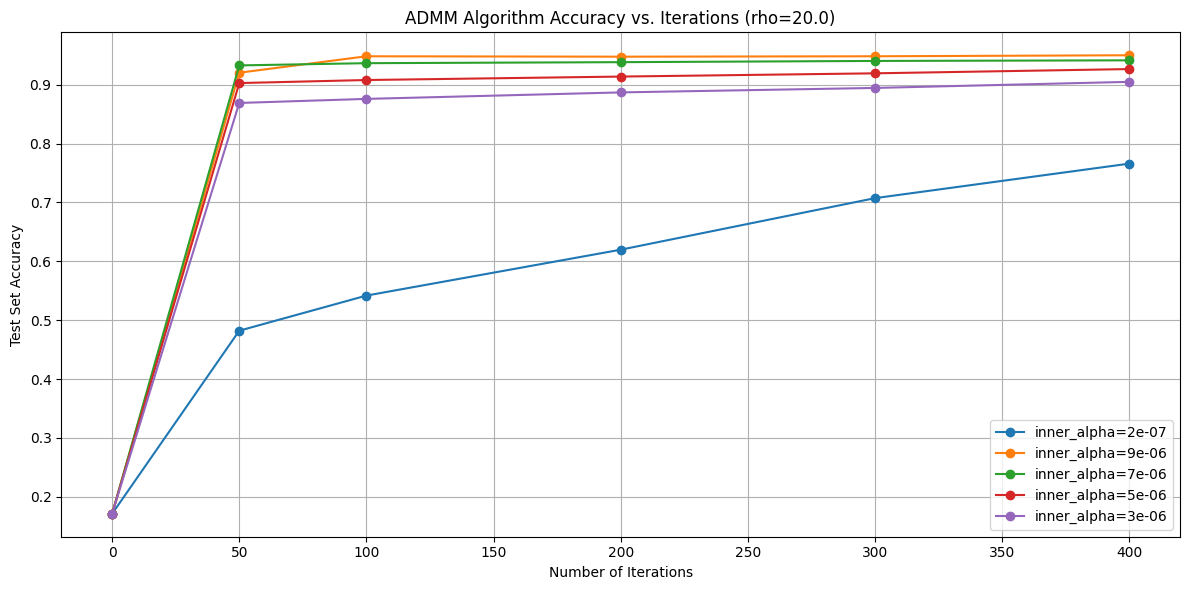

In [54]:
inner_alpha_values_to_compare = [2e-7,9e-6,7e-6,5e-6, 3e-6, ]
fixed_rho = 20.0 

compare_admm_inner_alphas(...)

Modifions le $\rho=20000$.

Initial Accuracy (x0): 0.1710

Running ADMM algorithm with fixed_rho=20000.0, inner_alpha_x_sub=2e-07
ADMM Iter    0: Obj = 19454.7188, Primal = 0.0025, Dual = 54.3429
ADMM Iter  100: Obj = 15683.4365, Primal = 0.0001, Dual = 43.2205
ADMM Iter  200: Obj = 13867.4727, Primal = 0.0000, Dual = 33.9961
ADMM Iter  300: Obj = 12649.0020, Primal = 0.0000, Dual = 28.8744
ADMM Iter  400: Obj = 11731.6504, Primal = 0.0000, Dual = 25.5191
  Accuracies for inner_alpha=2e-07: ['0.4821', '0.5417', '0.6197', '0.7072', '0.7655']

Running ADMM algorithm with fixed_rho=20000.0, inner_alpha_x_sub=9e-06
ADMM Iter    0: Obj = 26921.5430, Primal = 0.0029, Dual = 11591.9766
ADMM Iter  100: Obj = 3359.8928, Primal = 0.0002, Dual = 468.8576
ADMM Iter  200: Obj = 2267.2932, Primal = 0.0001, Dual = 278.5578
ADMM Iter  300: Obj = 1689.0620, Primal = 0.0000, Dual = 190.3981
ADMM Iter  400: Obj = 1569.5183, Primal = 0.0000, Dual = 30.7954
  Accuracies for inner_alpha=9e-06: ['0.8552', '0.9103', '0.9397', '0.9514', 

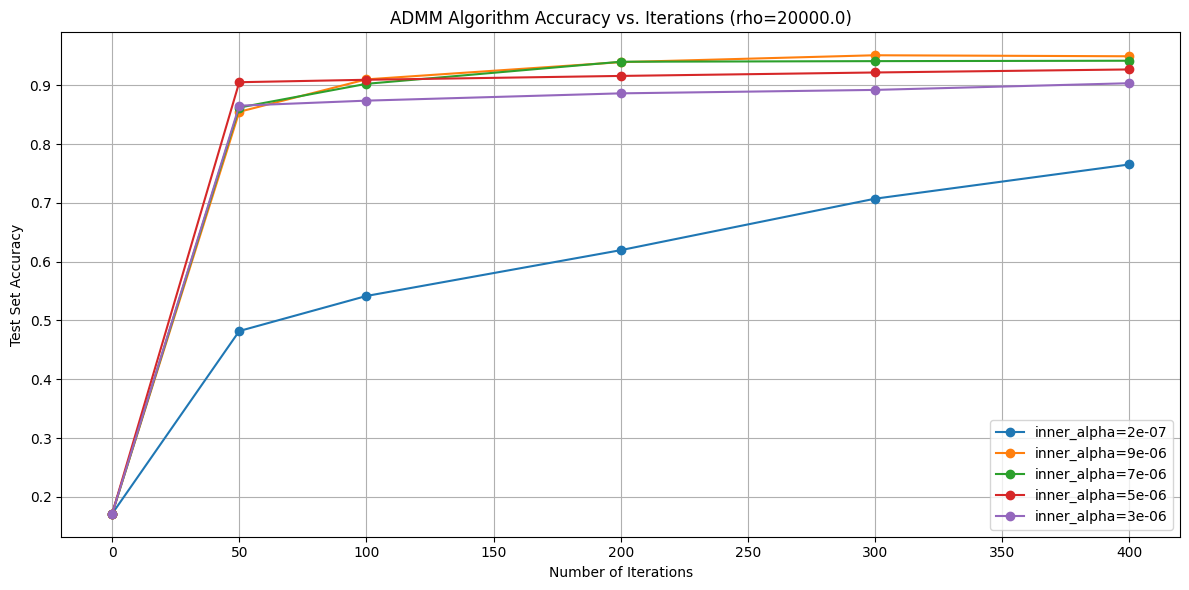

In [59]:
inner_alpha_values_to_compare = [2e-7,9e-6,7e-6,5e-6, 3e-6, ]
fixed_rho = 20000.0 
compare_admm_inner_alphas(...)

Nous allons redéfinir les algorithmes Condat et ADMM pour les limiter par un temps maximal d'exécution et un nombre maximal d'itérations.

In [65]:
import time

def condat_algorithm_torch_timed(...,max_time=None, time_record_interval=None):

In [66]:
import time

def admm_solver_torch_timed(...,max_time=None, time_record_interval=None):

Nous allons effectuer une comparaison finale du temps d'exécution de nos deux modèles, en utilisant les meilleurs hyperparamètres trouvés de manière théorique.

Starting time-based comparison of Condat and ADMM algorithms...
Initial accuracy (x0): 0.1710

--- Running Condat Algorithm ---
Condat final accuracy: 0.9372 in 71.57s

--- Running ADMM Algorithm ---
ADMM Iter    0: Obj = 21435.2754, Primal = 1.1288, Dual = 10.6130
ADMM Iter  100: Obj = 1699.9990, Primal = 0.0162, Dual = 0.1323
ADMM Iter  200: Obj = 1663.0359, Primal = 0.0058, Dual = 0.0361
ADMM Iter  300: Obj = 1630.5553, Primal = 0.0071, Dual = 0.0334
ADMM Iter  400: Obj = 1600.9362, Primal = 0.0062, Dual = 0.0320
ADMM Iter  500: Obj = 1573.6832, Primal = 0.0052, Dual = 0.0342
ADMM Iter  600: Obj = 1548.5662, Primal = 0.0059, Dual = 0.0295
ADMM Iter  700: Obj = 1525.2845, Primal = 0.0063, Dual = 0.0284
ADMM Iter  800: Obj = 1503.6194, Primal = 0.0068, Dual = 0.0274
ADMM Iter  900: Obj = 1483.4885, Primal = 0.0069, Dual = 0.0435
ADMM Iter 1000: Obj = 1464.6475, Primal = 0.0065, Dual = 0.0256
ADMM Iter 1100: Obj = 1447.0116, Primal = 0.0066, Dual = 0.0249
ADMM Iter 1200: Obj = 1430.412

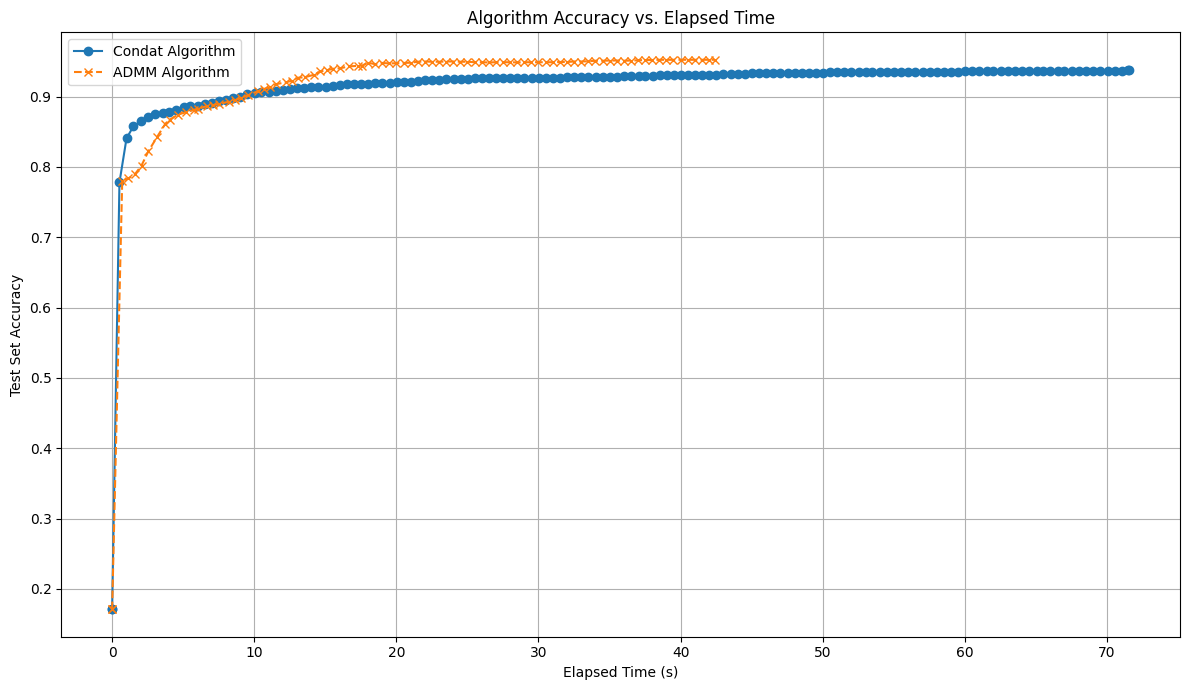

Comparison complete.


In [72]:
def compare_algorithms_by_time(...,
    max_time_limit, max_iterations, time_record_interval,
    condat_tau, condat_rho, admm_rho, admm_inner_alpha_x_sub
):

condat_tau_best = 2.06e-6 
condat_rho_best = 1.5 

admm_rho_best = 20.0 
admm_inner_alpha_best = 9e-6 

max_time = 600 # seconds
max_iters = 2000 # Max iterations for each algorithm if time limit is not hit
time_interval = 0.5 # Record every 0.5 seconds

compare_algorithms_by_time(...)

On peut en déduire qu'à partir d'un certain moment, l'algorithme ADMM obtient de meilleures performances en termes de temps de calcul avec les hyperparamètres suivants :

In [74]:
condat_tau_best = 2.06e-6
condat_rho_best = 1.5

admm_rho_best = 20.0
admm_inner_alpha_best = 9e-6